# Exploratary Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("data/ResalePricesSingapore.csv")
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
0,2014-01,ANG MO KIO,2 ROOM,510,ANG MO KIO AVE 8,07 TO 09,44.0,Improved,1980,280000.0
1,2014-01,ANG MO KIO,3 ROOM,603,ANG MO KIO AVE 5,07 TO 09,67.0,New Generation,1980,290000.0
2,2014-01,ANG MO KIO,3 ROOM,476,ANG MO KIO AVE 10,04 TO 06,67.0,New Generation,1979,300000.0
3,2014-01,ANG MO KIO,3 ROOM,558,ANG MO KIO AVE 10,01 TO 03,67.0,New Generation,1980,315000.0
4,2014-01,ANG MO KIO,3 ROOM,605,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,318000.0


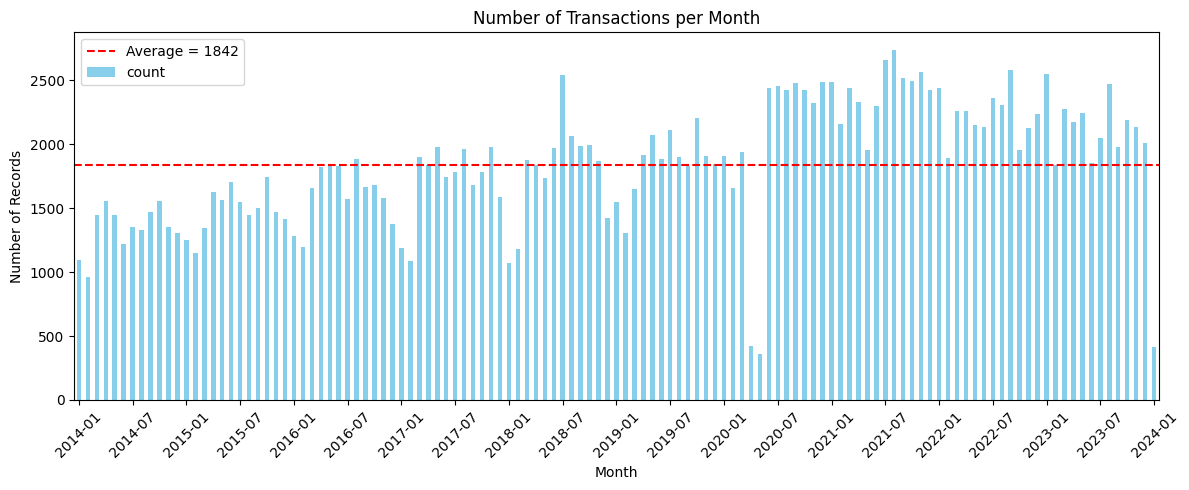

In [6]:
# Convert 'month' column to datetime format
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Count number of records per month
monthly_counts = df['month'].value_counts().sort_index()
average_count = monthly_counts.mean()

# Plot bar chart
ax = monthly_counts.plot(kind='bar', figsize=(12, 5), color='skyblue')
ax.set_title("Number of Transactions per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Records")

# Add average line
plt.axhline(y=average_count, color='red', linestyle='--', label=f'Average = {average_count:.0f}')
plt.legend()

# Reduce x-ticks
ax.set_xticks(range(0, len(monthly_counts), 6))  # every 6th bar
ax.set_xticklabels([monthly_counts.index[i].strftime('%Y-%m') for i in range(0, len(monthly_counts), 6)], rotation=45)

plt.tight_layout()
plt.show()

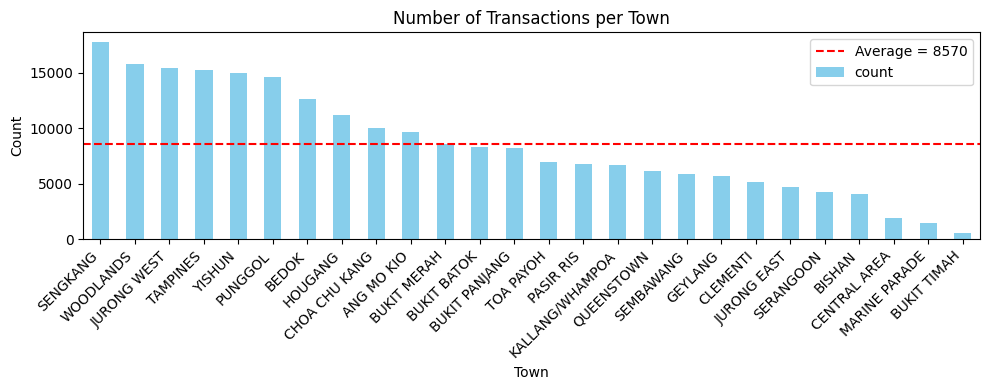

In [ ]:
# Compute town counts and their average
town_counts = df["town"].value_counts().sort_values(ascending=False)
average_town_count = town_counts.mean()

# Plot
plt.figure(figsize=(10, 4))
town_counts.plot(kind='bar', color='skyblue')
plt.axhline(y=average_town_count, color='red', linestyle='--', label=f'Average = {average_town_count:.0f}')
plt.legend()

plt.title('Number of Transactions per Town')
plt.xlabel("Town")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

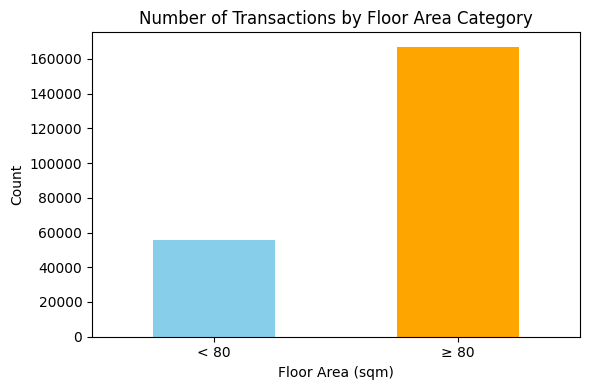

In [5]:
area_categories = pd.Series(
    ["< 80" if x < 80 else "≥ 80" for x in df["floor_area_sqm"]],
    name="Floor Area Category"
)

area_counts = area_categories.value_counts().sort_index()

plt.figure(figsize=(6, 4))
area_counts.plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Number of Transactions by Floor Area Category")
plt.ylabel("Count")
plt.xlabel("Floor Area (sqm)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()